#  Spam classification with Naive Bayes and Support Vector Machines.

- Libraries
- Exploring the Dataset
- Distribution spam and non-spam plots
- Text Analytics
- Feature Engineering
- Predictive analysis (**Multinomial Naive Bayes and Support Vector Machines**)
- Conclusion


## Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn import feature_extraction, model_selection, naive_bayes, metrics, svm
from IPython.display import Image
import warnings
import seaborn as sns
warnings.filterwarnings("ignore")
%matplotlib inline  

## Exploring the Dataset

In [3]:
data = pd.read_csv('spam.csv', encoding='latin-1')
data.head(n=10)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
5,spam,FreeMsg Hey there darling it's been 3 week's n...,NaN,NaN,NaN
6,ham,Even my brother is not like to speak with me. ...,NaN,NaN,NaN
7,ham,As per your request 'Melle Melle (Oru Minnamin...,NaN,NaN,NaN
8,spam,WINNER!! As a valued network customer you have...,NaN,NaN,NaN
9,spam,Had your mobile 11 months or more? U R entitle...,NaN,NaN,NaN


## Distribution spam/non-spam plots

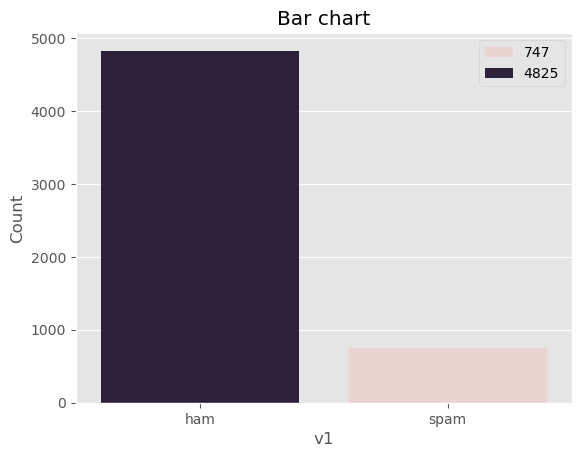

In [4]:
plt.style.use("ggplot")

# count values
count_class = data["v1"].value_counts()

# seaborn barplot
sns.barplot(
    x=count_class.index,
    y=count_class.values,
    hue=count_class.values,
)

plt.title("Bar chart")
plt.xlabel("v1")
plt.ylabel("Count")
plt.show()

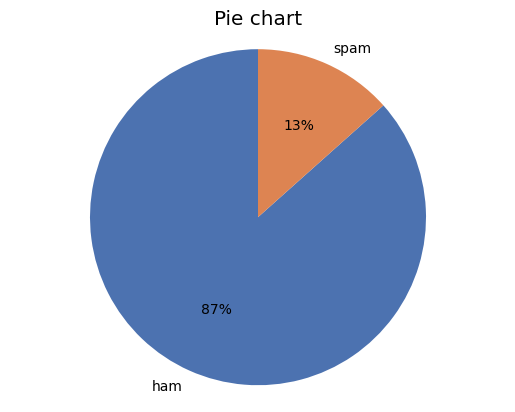

In [5]:
colors = sns.color_palette("deep", len(count_class))

# pie chart
plt.pie(
    count_class.values,
    labels=count_class.index,
    autopct="%1.0f%%",
    colors=colors,
    startangle=90
)

plt.title("Pie chart")
plt.ylabel("")  # remove y-label
plt.axis("equal")  # make it a circle
plt.show()

## Text Analytics

We want to find the frequencies of words in the spam and non-spam messages. The words of the messages will be model features.<p>
We use the function Counter.

In [6]:
count1 = Counter(" ".join(data[data['v1']=='ham']["v2"]).split()).most_common(20)
df1 = pd.DataFrame.from_dict(count1)
df1 = df1.rename(columns={0: "words in non-spam", 1 : "count"})
count2 = Counter(" ".join(data[data['v1']=='spam']["v2"]).split()).most_common(20)
df2 = pd.DataFrame.from_dict(count2)
df2 = df2.rename(columns={0: "words in spam", 1 : "count_"})

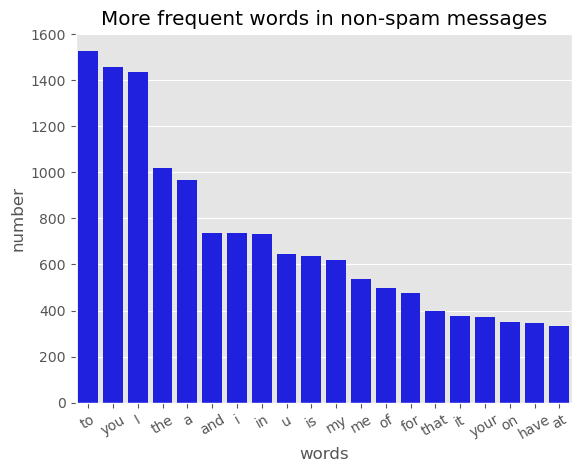

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

sns.barplot(
    x=df1["words in non-spam"],  # non-spam words
    y=df1["count"],              # their counts
    color="blue"
)

plt.title("More frequent words in non-spam messages")
plt.xlabel("words")
plt.ylabel("number")
plt.xticks(rotation=30)  # tilt x-labels for readability
plt.show()


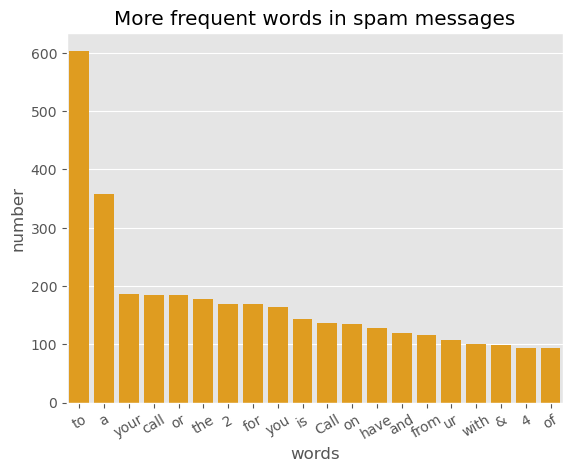

In [9]:
plt.style.use("ggplot")

sns.barplot(
    x=df2["words in spam"],
    y=df2.iloc[:, 1],
    color="orange"
)

plt.title("More frequent words in spam messages")
plt.xlabel("words")
plt.ylabel("number")
plt.xticks(rotation=30)  # tilt labels 30 degrees
plt.show()

We can see that the majority of frequent words in both classes are stop words such as 'to', 'a', 'or' and so on. <p>
With stop words we refer to the most common words in a lenguage, there is no simgle, universal list of stop words. <p>

In [13]:

from collections import Counter
import pandas as pd

# ---- Non-spam ----
total_non_spam = df1['count'].sum()  # total count of all words in non-spam
df1['probability'] = df1['count'] / total_non_spam

print("Top 3 non-spam words with probabilities:")
print(df1[['words in non-spam', 'count', 'probability']].head(3))
print("\n")

# ---- Spam ----
total_spam = df2['count_'].sum()  # total count of all words in spam
df2['probability'] = df2['count_'] / total_spam

print("Top 3 spam words with probabilities:")
print(df2[['words in spam', 'count_', 'probability']].head(3))

Top 3 non-spam words with probabilities:
  words in non-spam  count  probability
0                to   1530     0.107678
1               you   1458     0.102611
2                 I   1436     0.101063


Top 3 spam words with probabilities:
  words in spam  count_  probability
0            to     604     0.174164
1             a     358     0.103230
2          your     187     0.053922


Top 5 spam words:
     Word  Count  Probability
0    call    355     0.026805
1    free    224     0.016913
2     txt    163     0.012307
3  mobile    127     0.009589
4    text    125     0.009438

Top 5 non-spam words:
      Word  Count  Probability
2785   get    305     0.008081
2786    ok    287     0.007604
2787    go    249     0.006597
2788  know    236     0.006252
2789  good    233     0.006173


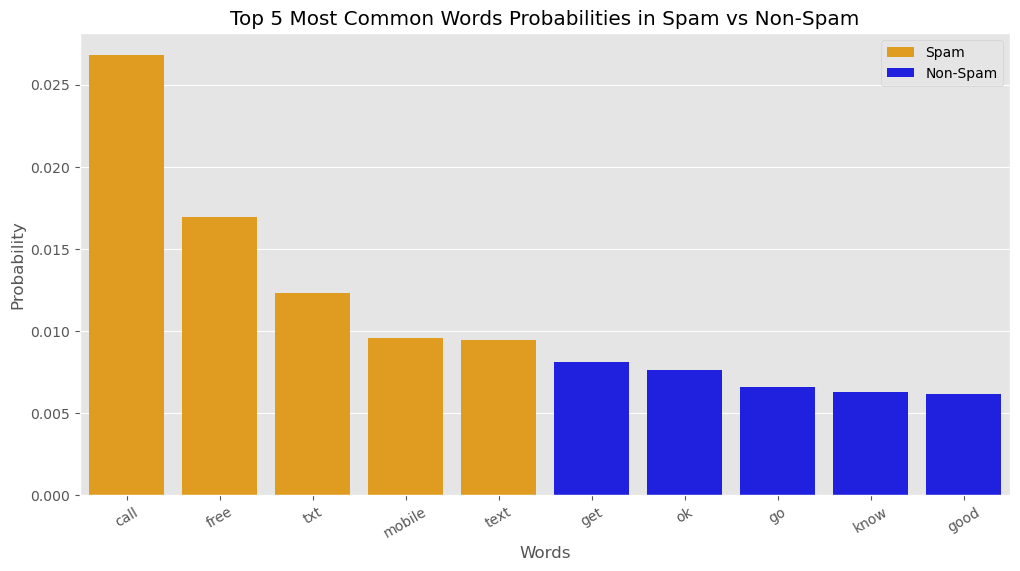

In [16]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load CSV
df1 = pd.read_csv("word_frequencies.csv")

# Split into spam and non-spam
df_spam = df1[df1['Label'] == 'spam'].copy()
df_non_spam = df1[df1['Label'] == 'ham'].copy()  # assuming 'ham' is non-spam

# Print top 5 most common words for each
print("Top 5 spam words:")
print(df_spam[['Word', 'Count', 'Probability']].head(5))
print("\nTop 5 non-spam words:")
print(df_non_spam[['Word', 'Count', 'Probability']].head(5))

# ---- Plot probabilities in the same graph ----
plt.style.use("ggplot")

plt.figure(figsize=(12,6))

# Plot spam probabilities
sns.barplot(
    x='Word', 
    y='Probability', 
    data=df_spam.head(5), 
    color='orange', 
    label='Spam'
)

# Plot non-spam probabilities on the same axes
sns.barplot(
    x='Word', 
    y='Probability', 
    data=df_non_spam.head(5), 
    color='blue', 
    label='Non-Spam'
)

plt.title("Top 5 Most Common Words Probabilities in Spam vs Non-Spam")
plt.ylabel("Probability")
plt.xlabel("Words")
plt.xticks(rotation=30)
plt.legend()
plt.show()

In [ ]:
df_cleaned=pd.read_csv('spam_cleaned.csv')
df_cleaned.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4,cleaned_text
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN,go until jurong point crazy available only in ...
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN,free entry in a wkly comp to win fa cup final ...
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN,u dun say so early hor u c already then say
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN,nah i don t think he goes to usf he lives arou...


## Feature engineering

Text preprocessing, tokenizing and filtering of stopwords are included in a high level component that is able to build a dictionary of features and transform documents to feature vectors.<p>
**We remove the stop words in order to improve the analytics**

In [22]:
f = feature_extraction.text.CountVectorizer(stop_words = 'english')
X = f.fit_transform(data["v2"])
np.shape(X)

(5572, 8404)

In [29]:

print(X)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 43478 stored elements and shape (5572, 8404)>
  Coords	Values
  (0, 4224)	1
  (0, 5741)	1
  (0, 2271)	1
  (0, 1271)	1
  (0, 1703)	1
  (0, 3534)	1
  (0, 8227)	1
  (0, 4349)	1
  (0, 1701)	1
  (0, 1994)	1
  (0, 3494)	1
  (0, 1051)	1
  (0, 8026)	1
  (1, 5343)	1
  (1, 4385)	1
  (1, 4192)	1
  (1, 8134)	1
  (1, 5369)	1
  (2, 3265)	1
  (2, 2875)	2
  (2, 8185)	1
  (2, 2110)	1
  (2, 8146)	1
  (2, 3005)	2
  (2, 2329)	1
  :	:
  (5567, 309)	1
  (5567, 700)	1
  (5567, 5801)	1
  (5567, 165)	1
  (5567, 5264)	1
  (5568, 3789)	1
  (5568, 3463)	1
  (5568, 8390)	1
  (5568, 3252)	1
  (5568, 2907)	1
  (5569, 4992)	1
  (5569, 5673)	1
  (5569, 7168)	1
  (5570, 3265)	1
  (5570, 8071)	1
  (5570, 4485)	1
  (5570, 2532)	1
  (5570, 3373)	1
  (5570, 1737)	1
  (5570, 3587)	1
  (5570, 4040)	1
  (5570, 900)	1
  (5570, 1500)	1
  (5571, 7656)	1
  (5571, 6323)	1


We have created more than 8400 new features. The new feature $j$ in the row $i$ is equal to 1 if the word $w_{j}$ appears in the text example $i$. It is zero if not.

## Predictive Analysis

**My goal is to predict if a new sms is spam or non-spam. I assume that is much worse misclassify non-spam than misclassify an spam. (I don't want to have false positives)**
<p>
The reason is because I normally don't check the spam messages.<p> The two possible situations are:<p>
1. New spam sms in my inbox. (False negative).<p>
OUTCOME: I delete it.<p>
2. New non-spam sms in my spam folder (False positive).<p>  OUTCOME: I probably don't read it. <p>
I prefer the first option!!!

First we transform the variable spam/non-spam into binary variable, then we split our data set in training set and test set. 

In [9]:
data["v1"]=data["v1"].map({'spam':1,'ham':0})
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, data['v1'], test_size=0.33, random_state=42)
print([np.shape(X_train), np.shape(X_test)])

[(3733, 8404), (1839, 8404)]


### Multinomial naive bayes classifier

In [10]:
list_alpha = np.arange(1/100000, 20, 0.11)
score_train = np.zeros(len(list_alpha))
score_test = np.zeros(len(list_alpha))
recall_test = np.zeros(len(list_alpha))
precision_test= np.zeros(len(list_alpha))
count = 0
for alpha in list_alpha:
    bayes = naive_bayes.MultinomialNB(alpha=alpha)
    bayes.fit(X_train, y_train)
    score_train[count] = bayes.score(X_train, y_train)
    score_test[count]= bayes.score(X_test, y_test)
    recall_test[count] = metrics.recall_score(y_test, bayes.predict(X_test))
    precision_test[count] = metrics.precision_score(y_test, bayes.predict(X_test))
    count = count + 1 

Let's see the first 10 learning models and their metrics!

In [11]:
matrix = np.matrix(np.c_[list_alpha, score_train, score_test, recall_test, precision_test])
models = pd.DataFrame(data = matrix, columns = 
             ['alpha', 'Train Accuracy', 'Test Accuracy', 'Test Recall', 'Test Precision'])
models.head(n=10)

,alpha,Train Accuracy,Test Accuracy,Test Recall,Test Precision
0,0.00001,0.998661,0.974443,0.920635,0.895753
1,0.11001,0.997857,0.976074,0.936508,0.893939
2,0.22001,0.997857,0.977162,0.936508,0.900763
3,0.33001,0.997589,0.977162,0.936508,0.900763
4,0.44001,0.997053,0.977162,0.936508,0.900763
5,0.55001,0.996250,0.976618,0.936508,0.897338
6,0.66001,0.996518,0.976074,0.932540,0.896947
7,0.77001,0.996518,0.976074,0.924603,0.903101
8,0.88001,0.996250,0.976074,0.924603,0.903101
9,0.99001,0.995982,0.976074,0.920635,0.906250


I select the model with the most test precision

In [12]:
best_index = models['Test Precision'].idxmax()
models.iloc[best_index, :]

alpha             15.730010
Train Accuracy     0.979641
Test Accuracy      0.969549
Test Recall        0.777778
Test Precision     1.000000
Name: 143, dtype: float64

**My best model does not produce any false positive, which is our goal.** <p>
Let's see if there is more than one model with 100% precision !

In [13]:
models[models['Test Precision']==1].head(n=5)

,alpha,Train Accuracy,Test Accuracy,Test Recall,Test Precision
143,15.73001,0.979641,0.969549,0.777778,1.0
144,15.84001,0.979641,0.969549,0.777778,1.0
145,15.95001,0.979641,0.969549,0.777778,1.0
146,16.06001,0.979373,0.969549,0.777778,1.0
147,16.17001,0.979373,0.969549,0.777778,1.0


Between these models with the highest possible precision, we are going to select which has more test accuracy.

In [14]:
best_index = models[models['Test Precision']==1]['Test Accuracy'].idxmax()
bayes = naive_bayes.MultinomialNB(alpha=list_alpha[best_index])
bayes.fit(X_train, y_train)
models.iloc[best_index, :]

alpha             15.730010
Train Accuracy     0.979641
Test Accuracy      0.969549
Test Recall        0.777778
Test Precision     1.000000
Name: 143, dtype: float64

#### Confusion matrix with naive bayes classifier

In [15]:
m_confusion_test = metrics.confusion_matrix(y_test, bayes.predict(X_test))
pd.DataFrame(data = m_confusion_test, columns = ['Predicted 0', 'Predicted 1'],
            index = ['Actual 0', 'Actual 1'])

,Predicted 0,Predicted 1
Actual 0,1587,0
Actual 1,56,196


* #### We misclassify 56 spam messages as non-spam emails whereas we don't misclassify any non-spam message.